# FARGOpy
## Wrapping FRAGO3D

### What's in this notebook


This notebook demonstrates how to use the `FARGOpy` library to perform advanced calculations and analyses on simulation data from `FARGO3D`. The main focus is on calculating integrals over a general surface or volume and visualizing the results.

Key sections include:

- **Creating a surfac Object**: Define a surface/volume for 2D,3D analysis, specifying its parameters (Sphere,Cilinder only available for now)

- **Analyzing Data**:
  - Create an `Analyzer` object to perform calculations on the simulation data.
  - Define custom integrand functions for specific analyses, such as calculating flux over a surface.

- **Performing Integrals**:
  - Calculate integrals over a surface or volume using the `Analyzer` object.
  - Use a user-defined integrand function to compute the desired quantity, such as flux or other physical properties.

- **Visualizing Results**:
  - Plot the calculated results as a function of time.
  - Highlight key metrics, such as the average value of the computed integral, for better interpretation.

This notebook serves as a practical guide for users to explore and analyze `FARGO3D` simulation data using `FARGOpy`, focusing on integral-based calculations and their visualization.

### Before starting

If you are in `Google Colab`, install the latest version of the package:

In [1]:
# @title Install fargopy
import sys
if 'google.colab' in sys.modules:
    !sudo pip install -Uq fargopy

For this tutorial you will need the following external modules and tools:

In [12]:
import fargopy as fp
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Let's `FARGOpy`

First we need the data. Let's download a precomputed simulation. Check the list:

In [13]:
fp.Simulation.list_precomputed()

fargo:
	Description: Protoplanetary disk with a Jovian planet [2D]
	Size: 55 MB
p3diso:
	Description: Protoplanetary disk with a Super earth planet [3D]
	Size: 220 MB
p3disoj:
	Description: Protoplanetary disk with a Jovian planet [3D]
	Size: 84 MB
fargo_multifluid:
	Description: Protoplanetary disk with several fluids (dust) and a Jovian planet in 2D
	Size: 100 MB
binary:
	Description: Disk around a binary with the properties of Kepler-38 in 2D
	Size: 140 MB


Download, for instance, the 3D simulation of a disk with a Jovian planet:

In [4]:
fp.Simulation.download_precomputed('p3disoj')

Precomputed output directory '/tmp/p3disoj' already exist


'/tmp/p3disoj'

Once download it, we need to connect a `Simulation` with the directory with the simulation results:

In [5]:
sim = fp.Simulation(output_dir='/tmp/p3disoj')

Your simulation is now connected with '/home/jupitergeci/fargo3d/'
Now you are connected with output directory '/tmp/p3disoj'
Found a variables.par file in '/tmp/p3disoj', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 128 [[0, np.float64(-3.117048960983623)], [-1, np.float64(3.117048960983623)]]
	Variable r: 64 [[0, np.float64(0.5078125)], [-1, np.float64(1.4921875)]]
	Variable theta: 32 [[0, np.float64(1.4231400767948967)], [-1, np.float64(1.5684525767948965)]]
Number of snapshots in output directory: 11
Planets found in summary.dat:
  Name: Jupiter, Distance: 1.0, Mass: 0.001
Configuration variables and domains load into the object. See e.g. <sim>.vars


Now we load the data from `FARGO3D`simulation results for a visualization:

In [6]:
dataXY = sim.load_field(
    fields='gasdens',
    slice='r=[0.8,1.2],phi=[-25 deg,25 deg],theta=1.56',
    snapshot=10,
)



dataXZ = sim.load_field(
    fields='gasdens',
    slice='phi=0',
    snapshot=10,
)

Now create the sphere object from `fargopy.Surface`, let's see the simulation planet properties:

In [7]:
sim.load_macros()
sim.load_planet_summary()


[{'name': 'Jupiter', 'distance': 1.0, 'mass': 0.001}]

Now set the sphere radius as the Hill Radius:

In [8]:
r_hill = sim.hill_radius()[1] # [1] is the hill radius in sim units, [0] un gcs

sphere = fp.Surface.Sphere(radius=r_hill, subdivisions=1, center=(1.0, 0.0, 0.0))

In [9]:
type(sphere)

fargopy.flux.Surface.Sphere

Visualize the sphere object

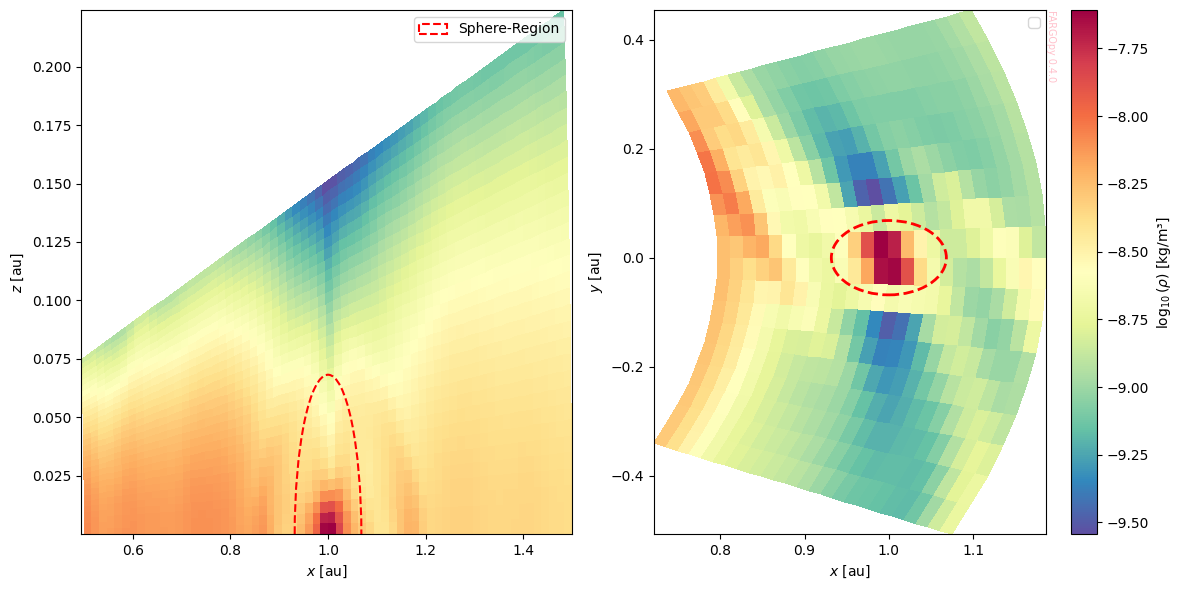

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

cmap = 'Spectral_r'

# Colormap of the logarithmic density for the XZ plane
ax = axs[0]
pc = ax.pcolormesh(
    dataXZ.mesh.x * sim.UL / fp.AU,
    dataXZ.mesh.z * sim.UL / fp.AU,
    np.log10(dataXZ.data * sim.URHO ),
    cmap=cmap
)
ax.set_xlabel('$x$ [au]')
ax.set_ylabel('$z$ [au]')

# Add a circle to the XZ plane
circle_xz = plt.Circle(
    (sphere.center[0], sphere.center[2]),  # Center in the XZ plane
    sphere.radius * sim.UL / fp.AU,        # Radius in AU
    color='red',
    fill=False,
    linestyle='--',
    linewidth=1.5,
    label='Sphere-Region'
)
ax.add_artist(circle_xz)
ax.legend()

# Colormap of the logarithmic density for the XY plane
ax = axs[1]
pc = ax.pcolormesh(
    dataXY.mesh.x * sim.UL / fp.AU,
    dataXY.mesh.y * sim.UL / fp.AU,
    np.log10(dataXY.data * sim.URHO ),
    cmap=cmap
)
ax.set_xlabel('$x$ [au]')
ax.set_ylabel('$y$ [au]')

# Add a circle to the XY plane
circle_xy = plt.Circle(
    (sphere.center[0], sphere.center[1]),  # Center in the XY plane
    sphere.radius * sim.UL / fp.AU,        # Radius in AU
    color='red',
    fill=False,
    linestyle='--',
    linewidth=2,
    
)
ax.add_artist(circle_xy)
ax.legend()

# Add colorbar
fig.colorbar(pc, ax=axs[1], label=r"$\log_{10}(\rho)$ [kg/m³]")
fp.Plot.fargopy_mark(ax)

plt.tight_layout()
plt.show()

## 2D Surface Visualization

Create the `Sphere` object filtered for $z>0.03$ (semi-sphere)


In [11]:
sphere = fp.Surface.Sphere(
    radius=r_hill, 
    subdivisions=6, 
    center=(1.0, 0.0, 0.0)
)


sphere.filter("z>0.003")


The sphere object have different atributes the most important are: `sphere.centers`, `sphere.areas` and `sphere.volumes` each one is an array of n-subdivision elements in wich are stored the centers,areas and volumes of the sphere tesselation. 

In [45]:
sphere.centers

array([[0.96268152, 0.05706851, 0.00311702],
       [0.96380414, 0.05776232, 0.00354583],
       [0.96494161, 0.05843221, 0.00397298],
       ...,
       [1.06273228, 0.02656919, 0.00421917],
       [1.063534  , 0.02470014, 0.00352086],
       [1.0632347 , 0.02545675, 0.00351967]], shape=(39148, 3))

Now we can interpolate the fields over the surface, specifically on the centers of tesselation triangles:

In [46]:
# Coordinates of the sphere centers
xcs=sphere.centers[:, 0]
ycs=sphere.centers[:, 1]
zcs=sphere.centers[:, 2]

In [47]:
# Load the 3D gas density field from the simulation
data3d = sim.load_field(
    fields='gasdens',
    snapshot=10,
    interpolate=True)



Loading density field


In [48]:
rho = data3d.evaluate(
   time=10,
   var1=xcs,
   var2=ycs,
   var3=zcs,
   interpolator='idw',
  idw_kwargs={"power": 2, "k": 30})

# Another 3D interpolator option
# rho = data3d.evaluate(
#     time=10,
#     var1=xcs,
#     var2=ycs,
#     var3=zcs,
#     interpolator='griddata',
#     method='nearest'
#     )
        

Running FARGOpy version 0.4.0


Lets see the 3D Density field over the surface:

In [49]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Scatter3d(
    x=xcs.flatten(),
    y=ycs.flatten(),
    z=zcs.flatten(),
    mode='markers',
    marker=dict(
        size=2,
        color=np.log(rho.flatten()),  # Color según la densidad interpolada
        colorscale='Spectral_r',
        opacity=1,
        colorbar=dict(title='Density log[g cm^-3]'),
    )
))

fig.update_layout(
    scene=dict(
        xaxis_title='X [au]',
        yaxis_title='Y [au]',
        zaxis_title='Z [au]',
        aspectmode='data'
    ),
    title='IDW Interpolation on Sphere Centers in 3D Gas Density Field',
)

fig.show()

## 2D Projection

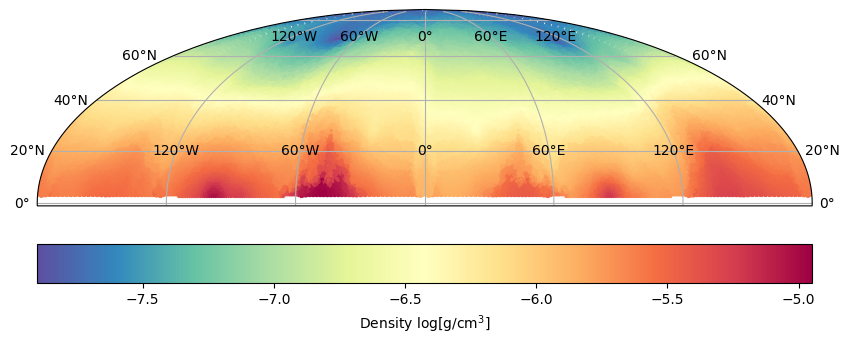

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

x0, y0, z0 = 1, 0, 0
xcs_shifted = xcs - x0
ycs_shifted = ycs - y0
zcs_shifted = zcs - z0

# Calculate the spherical coordinates
r = np.sqrt(xcs_shifted**2 + ycs_shifted**2 + zcs_shifted**2)
lat = np.degrees(np.arcsin(zcs_shifted / r))
lon = np.degrees(np.arctan2(ycs_shifted, xcs_shifted))


fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.Mollweide())
sc = ax.scatter(
    lon, lat, c=np.log(rho), s=2, cmap='Spectral_r',
    transform=ccrs.PlateCarree(), alpha=1
)
# ax.coastlines()  # <- No mostrar contorno
ax.gridlines(draw_labels=True)

plt.colorbar(sc, orientation='horizontal', pad=0.05, label='Density log[g/cm$^3$]')
plt.show()

## 2D Projection With Plotly

In [18]:
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


x0, y0, z0 = 1, 0, 0
xcs_shifted = xcs - x0
ycs_shifted = ycs - y0
zcs_shifted = zcs - z0


r = np.sqrt(xcs_shifted**2 + ycs_shifted**2 + zcs_shifted**2)
lat = np.degrees(np.arcsin(zcs_shifted / r))
lon = np.degrees(np.arctan2(ycs_shifted, xcs_shifted))


fig = go.Figure(go.Scattergeo(
    lon=lon,  
    lat=lat,  
    mode='markers',
    marker=dict(
        size=2,
        color=np.log(rho.flatten()),
        colorscale='Spectral_r',
        opacity=1,
        colorbar=dict(title='Density log[g cm^-3]')
    )
))

fig.update_geos(
    projection_type="mollweide",
    lataxis=dict(griddash="solid",range=[0,90],showgrid=True, gridcolor="black", gridwidth=1),
    lonaxis=dict(griddash="solid",range=[-180,180],showgrid=True, gridcolor="black", gridwidth=1),
    showcountries=False,
    showcoastlines=False,
    showland=False,
    showocean=False,
    showframe=False,
)
fig.update_layout(
    margin={"r":5,"t":20,"l":5,"b":20}
)
fig.show()

# Accretion Rate

Let's see an example of how to calculate the accretion rate through the surface, this is calculated as:

$$ \dot{M} = J = \int_s { \rho(\mathbf{r},t)\ \mathbf{v}(\mathbf{r},t) \cdot \mathbf{ds}}$$

First create the sphere object with radius equal to the Hill Radius:

In [99]:
sim.load_macros()
r_hill = sim.hill_radius()[1]

In [52]:
sphere = fp.Surface.Sphere(
    radius=r_hill, # 
    subdivisions=6, 
    center=(1.0, 0.0, 0.0)
)

sphere.filter("z>0.003")


Create the analyzer object, in this load the fields that are needed to calculate the relevant physical quantities, in this case to calculate the flow of matter on the surface need the density and velocity field, in addition define the snapshots on which will work, then choose the interpolant in this case idw.

In [53]:
analyzer= fp.Analyzer(
    simulation=sim,
    surface=sphere,
    fields=['gasdens','gasv'],
    snapshots=(0,10),
    interpolator='idw',
    interp_kwargs={"power": 3, "k": 20}
)

Loading density field
Loading velocity field


In [54]:
type(analyzer)

fargopy.flux.Analyzer

Now create a sphere object:



Define the integrand function, in this case flux over 3D surface:

In [55]:
dJ = lambda gasdens, gasv: gasdens * np.sum(gasv * sphere.normals, axis=1)

Calculate the flux integral, we need to define how many parts we will divide the snapshots into for temporal interpolation, also define `dtype='area'` since the integral is a surface integral:

In [57]:
J = analyzer.calculate_integral(integrand = dJ, time_steps=50, dtype='area')

Calculating integral:   0%|          | 0/50 [00:00<?, ?it/s]

Running FARGOpy version 0.4.0
Running FARGOpy version 0.4.0
Running FARGOpy version 0.4.0
Running FARGOpy version 0.4.0
Running FARGOpy version 0.4.0
Running FARGOpy version 0.4.0
Running FARGOpy version 0.4.0
Running FARGOpy version 0.4.0


Calculating integral: 100%|██████████| 50/50 [21:54<00:00, 26.28s/it]


Antes de hacer el grafico, manejemos unidades de tiempo que esten en terminos de orbitas del planeta, para ello hacemos lo siguiente:


In [102]:
orbits_num = sim.time_scale(scale='orbits')

In [104]:
print(f'Number of orbits of the planet in the simulation: {int(orbits_num)}')

Number of orbits of the planet in the simulation: 20


Now we can plot the results:

Note: To express the x-axis (time) in orbits, having already defined the time variable as an array from 0 to 1 with 50 entries (with which the time_steps temporal interpolations were made), the x-axis labels must be remapped as follows: `axs.set_xticks(np.linspace(0, 1, 10),
labels=[f'{int(i*orbits_num)}' for i in np.linspace(0, 1, 10)],
size=12`

Text(1, 1, 'FARGOpy 0.4.0')

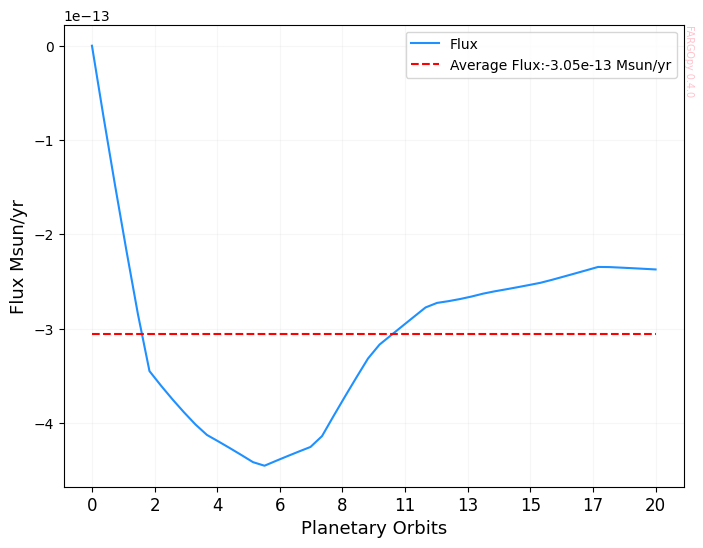

In [ ]:
flux_msun = J*sim.UM/sim.UT *1e-3*1/(1.989e30) # Convert to solar masses per year


flux_averaged = np.mean(flux_msun)


fig,axs = plt.subplots(1,1,figsize=(8,6))



axs.plot(np.linspace(0, 1, 50), flux_msun, label='Flux', color='dodgerblue')
axs.hlines(y=flux_averaged, xmin=0, xmax=1, color='red',
            linestyle='--', label=f'Average Flux:{flux_averaged:.2e} Msun/yr')
axs.set_xlabel('Planetary Orbits',size=13)
axs.set_ylabel('Flux Msun/yr',size=13)
axs.set_xticks(np.linspace(0, 1, 10),
              labels=[f'{int(i*orbits_num)}' for i in np.linspace(0, 1, 10)],
              size=12)

axs.legend()
axs.grid(alpha=0.1)
fp.Plot.fargopy_mark(axs)



## Matter flux heatmap in a single snapshot

Let's now look at a heat map on the surface of the sphere that shows us how the flow behaves on it.

In [118]:
sphere = fp.Surface.Sphere(
    radius=r_hill, 
    subdivisions=6, 
    center=(1.0, 0.0, 0.0)
)

sphere.filter("z>0.002")

Load the density an velocity fields for interpolation:

In [119]:

data_dens,data_vel = sim.load_field(
    fields=['gasdens','gasv'],
    snapshot = 10,
    interpolate=True)


Loading density field
Loading velocity field


### Surface Flux

Obtain the triangle tessellation center on the sphere

In [121]:
xcs = sphere.centers[:, 0]
ycs = sphere.centers[:, 1]
zcs = sphere.centers[:, 2]

Interpolate the data for know the density and velocity fields in the center of the triangle tessellation.

In [122]:
rho = data_dens.evaluate(
   time=10,
   var1=xcs,
   var2=ycs,
   var3=zcs,
   interpolator='idw',
  idw_kwargs={"power": 2, "k": 30})


vel = data_vel.evaluate(
   time=10,
   var1=xcs,
   var2=ycs,
   var3=zcs,
   interpolator='idw',
  idw_kwargs={"power": 2, "k": 30})

Running FARGOpy version 0.4.0
Running FARGOpy version 0.4.0
Running FARGOpy version 0.4.0
Running FARGOpy version 0.4.0


The matter flux (accretion rate) over a specifical region of the sphere surface is calculated as:

$$ dJ =   \rho(\mathbf{r},t)\ \mathbf{v}(\mathbf{r},t) \cdot \mathbf{ds}$$


In [123]:
Ms = rho * sphere.areas * np.sum(vel.T*sphere.normals,axis=1)

# Convert the mass flux to solar masses per year
M_sy = sim.UM/sim.UL**3 * sim.UL**2 * sim.UL/sim.UT * Ms *1.58667e-26




In [131]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Scatter3d(
    x=xcs.flatten(),
    y=ycs.flatten(),
    z=zcs.flatten(),
    mode='markers',
    marker=dict(
        size=2,
        color=M_sy,  
        colorscale='Spectral_r',
        opacity=1,
        colorbar=dict(tickformat=".2e",title='Planet Accretion Msun/yr'),
    )
))

fig.update_layout(
    scene=dict(
        xaxis_title='X [au]',
        yaxis_title='Y [au]',
        zaxis_title='Z [au]',
        aspectmode='data'
    ),
    title='Planet Accretion Rate on Sphere Centers in Planet '
)

fig.show()

### 2D Projection

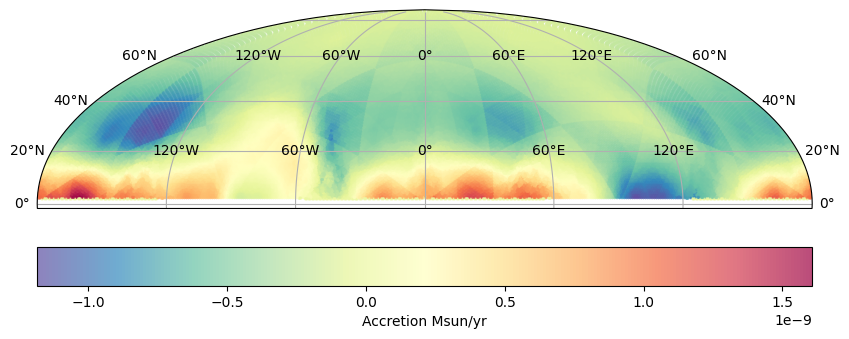

In [126]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


x0, y0, z0 = 1, 0, 0
xcs_shifted = xcs - x0
ycs_shifted = ycs - y0
zcs_shifted = zcs - z0


r = np.sqrt(xcs_shifted**2 + ycs_shifted**2 + zcs_shifted**2)
lat = np.degrees(np.arcsin(zcs_shifted / r))
lon = np.degrees(np.arctan2(ycs_shifted, xcs_shifted))


fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.Mollweide())
sc = ax.scatter(
    lon, lat, c=M_sy, s=2, cmap='Spectral_r',
    transform=ccrs.PlateCarree(), alpha=0.7
)

ax.gridlines(draw_labels=True)

plt.colorbar(sc, orientation='horizontal', pad=0.05, label='Accretion Msun/yr')
plt.show()